<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 135 · Forecasting Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Operationalizing a Forecast</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Take a demand forecaster to production: package it, serve it as a function an app can call, schedule a monthly refit, and monitor rolling accuracy. Then a regime shift hits, and watch a set-and-forget forecast rot to 28% error while the scheduled, monitored pipeline stays near 3%, the forecasting version of MLOps.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Case Study: Operationalizing a Forecast
A forecast that is right today can be wrong next quarter, because the world it learned from keeps changing. This final case study takes a demand forecaster all the way into production: **package** it, **serve** it as a function an app can call, **schedule** it to refresh, and **monitor** it for drift. Then a **regime shift** hits, and we watch a set-and-forget forecast rot while a scheduled, monitored pipeline stays fresh, the forecasting version of MLOps.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import joblib
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')
def ape(a,f): return np.abs((a-f)/a)*100

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The production contract</div>
<div style="color:#4a5578;margin-top:6px">What 'healthy in production' means for a forecast.</div>
</div>

In [3]:
CONTRACT = {
  'accuracy_floor_mape': 10.0,   # retrain trigger if rolling MAPE climbs above this
  'refresh_cadence': 'monthly',   # refit on the latest data every month
  'horizon': 6,                    # publish a 6-month-ahead forecast
  'monitor_window': 12,            # rolling window for the accuracy check
}
for k,v in CONTRACT.items(): print(f'{k:22s} {v}')
print('\nkey risk: a forecast decays as the series changes, so it must be REFRESHED and WATCHED, not set and forgotten.')

accuracy_floor_mape    10.0
refresh_cadence        monthly
horizon                6
monitor_window         12

key risk: a forecast decays as the series changes, so it must be REFRESHED and WATCHED, not set and forgotten.


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; COLLECT &amp; PACKAGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit the forecaster, then freeze it</div>
<div style="color:#4a5578;margin-top:6px">A deployable artifact is the model plus metadata.</div>
</div>

In [4]:
try: raw = pd.read_excel('../../data/case-study-operationalizing-a-forecast--demand_ops.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'case-study-operationalizing-a-forecast--demand_ops.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['demand'].asfreq('MS')
DEPLOY = 48                                   # deploy after 4 years of history
champion = ExponentialSmoothing(s[:DEPLOY], trend='add', seasonal='add', seasonal_periods=12).fit()
meta = {'model':'Holt-Winters','version':'v1.0','trained_through': str(s.index[DEPLOY-1].date()), 'n_train':DEPLOY}
joblib.dump({'model':champion,'meta':meta}, 'forecaster.joblib')
print('packaged forecaster.joblib'); print(meta)

packaged forecaster.joblib
{'model': 'Holt-Winters', 'version': 'v1.0', 'trained_through': '2019-12-01', 'n_train': 48}


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 3 &#183; SERVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A forecast service an app can call</div>
<div style="color:#4a5578;margin-top:6px">Load the artifact, return a forecast plus an interval.</div>
</div>

In [5]:
def forecast_service(bundle, horizon=6):
    m = bundle['model']; mean = m.forecast(horizon)
    sims = m.simulate(horizon, repetitions=1000); lo, hi = sims.quantile(0.025,axis=1), sims.quantile(0.975,axis=1)
    return {'as_of': bundle['meta']['trained_through'], 'version': bundle['meta']['version'],
            'forecast': mean.round(0).tolist(), 'lower': lo.round(0).tolist(), 'upper': hi.round(0).tolist()}
response = forecast_service(joblib.load('forecaster.joblib'), horizon=6)
print('what the /forecast endpoint returns (a dashboard or app consumes this):')
for k in ['as_of','version','forecast']: print(' ', k, ':', response[k])

what the /forecast endpoint returns (a dashboard or app consumes this):
  as_of : 2019-12-01
  version : v1.0
  forecast : [1171.0, 1115.0, 1239.0, 1336.0, 1360.0, 1424.0]


In production the forecaster sits behind a small <strong>service</strong>: load the packaged artifact once, and return a forecast with a prediction interval as a simple payload (here a Python dict, in practice a JSON API response). A <strong>dashboard, an app, or the order system from Chapter 134</strong> calls this endpoint, it never touches the model internals. That decoupling is what makes the forecast reusable.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 4 &#183; SCHEDULE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Refit on a cadence</div>
<div style="color:#4a5578;margin-top:6px">The forecasting-specific production step.</div>
</div>

In [6]:
# scheduled refresh: each month, refit on ALL data so far and forecast one step ahead
scheduled_fc = []
for m in range(DEPLOY, len(s)):
    fit = ExponentialSmoothing(s[:m], trend='add', seasonal='add', seasonal_periods=12).fit()
    scheduled_fc.append(float(fit.forecast(1).iloc[0]))
scheduled_fc = np.array(scheduled_fc)
print('scheduled a monthly refit; produced %d one-step forecasts as new data arrived' % len(scheduled_fc))
print('this is the difference from a one-time model: the scheduled job keeps the forecaster current.')

scheduled a monthly refit; produced 48 one-step forecasts as new data arrived
this is the difference from a one-time model: the scheduled job keeps the forecaster current.


Unlike a classifier, a forecaster has an obvious refresh rule: as each new month lands, <strong>refit on the latest data</strong> and forecast forward. Scheduling that job (a nightly or monthly cron) is the single most important production habit for forecasting, it lets the model absorb gradual change automatically. We keep both a scheduled pipeline and the original set-and-forget champion, to see the difference.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 5 &#183; LOG</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Record every forecast and its outcome</div>
<div style="color:#4a5578;margin-top:6px">You cannot monitor what you did not log.</div>
</div>

In [7]:
champion_fc = joblib.load('forecaster.joblib')['model'].forecast(len(s)-DEPLOY).values   # the static, never-refreshed forecast
log = pd.DataFrame({'month': s.index[DEPLOY:], 'actual': s.values[DEPLOY:],
                    'champion_setforget': champion_fc.round(0), 'scheduled_refit': scheduled_fc.round(0)}).set_index('month')
print(log.head(3))

            actual  champion_setforget  scheduled_refit
month                                                  
2020-01-01    1184              1171.0           1171.0
2020-02-01    1161              1115.0           1116.0
2020-03-01    1202              1239.0           1243.0


Both pipelines write every forecast to a <strong>log</strong>, and the actual demand is joined in when it arrives. The <strong>champion</strong> here is the forecast made <em>once</em> at deployment and never updated (a 4-year-ahead projection); the <strong>scheduled</strong> pipeline refits monthly. This log is the raw material for monitoring.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 6 &#183; MONITOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Watch rolling accuracy over time</div>
<div style="color:#4a5578;margin-top:6px">A silent decay becomes visible.</div>
</div>

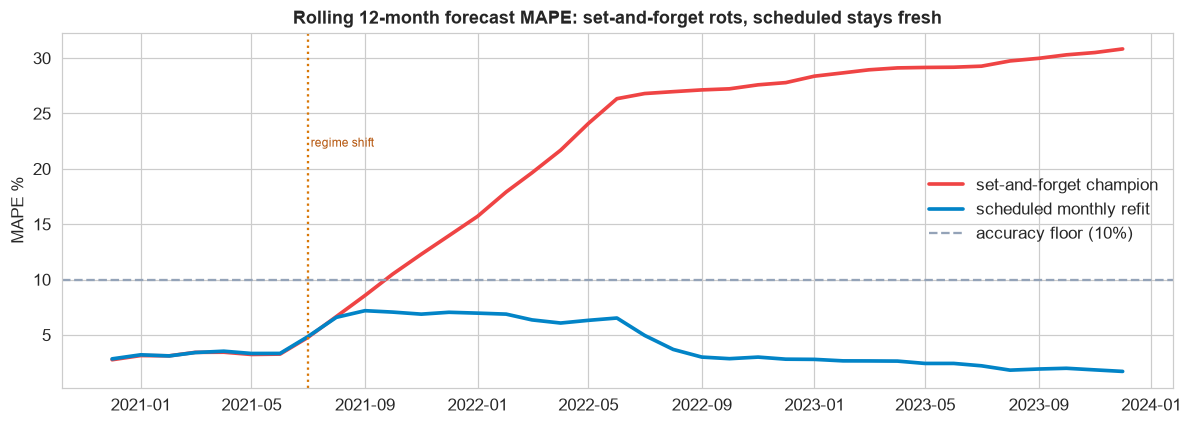

In [8]:
W = CONTRACT['monitor_window']
log['champ_ape'] = ape(log['actual'], log['champion_setforget'])
log['sched_ape'] = ape(log['actual'], log['scheduled_refit'])
roll = log[['champ_ape','sched_ape']].rolling(W).mean()
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(roll.index, roll['champ_ape'], color=RED, lw=2.4, label='set-and-forget champion')
ax.plot(roll.index, roll['sched_ape'], color=EM, lw=2.4, label='scheduled monthly refit')
ax.axhline(CONTRACT['accuracy_floor_mape'], color=GREY, ls='--', label='accuracy floor (10%)')
ax.axvline(pd.Timestamp('2021-07-01'), color=AMBER, ls=':', lw=1.5); ax.text(pd.Timestamp('2021-07-01'), 22, ' regime shift', color='#b45309', fontsize=8)
ax.set(title='Rolling 12-month forecast MAPE: set-and-forget rots, scheduled stays fresh', ylabel='MAPE %'); ax.legend(); plt.tight_layout(); plt.show()

Rolling accuracy tells the story at a glance. Both pipelines start near <strong>3% MAPE</strong>. Then something happens mid-2021, and the two lines split violently.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 7 &#183; DETECT DRIFT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The accuracy floor is breached</div>
<div style="color:#4a5578;margin-top:6px">The alarm the ops team acts on.</div>
</div>

In [9]:
breach = roll[roll['champ_ape'] > CONTRACT['accuracy_floor_mape']]
print('champion rolling MAPE first breaches the 10%% floor at:', breach.index[0].date())
print('champion post-shift rolling MAPE: %.1f%%  (was ~3%% before)' % log.loc['2021-08':,'champ_ape'].mean())
print('scheduled post-shift rolling MAPE: %.1f%%  (barely moved)' % log.loc['2021-08':,'sched_ape'].mean())
print('-> the ALARM fires on the champion; the scheduled pipeline never trips it.')

champion rolling MAPE first breaches the 10%% floor at: 2021-10-01
champion post-shift rolling MAPE: 28.5%  (was ~3% before)
scheduled post-shift rolling MAPE: 3.3%  (barely moved)
-> the ALARM fires on the champion; the scheduled pipeline never trips it.


A <strong>regime shift</strong>, a business expansion in July 2021, permanently lifted demand and steepened its growth. The <strong>set-and-forget champion</strong>, still projecting the old trajectory, is now catastrophically wrong: its rolling MAPE climbs to about <strong>28%</strong> and breaches the accuracy floor by October. That breach is the <strong>retraining trigger</strong>. The scheduled pipeline, meanwhile, barely notices.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 8 &#183; DIAGNOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Shock or regime change?</div>
<div style="color:#4a5578;margin-top:6px">A permanent shift needs new data, not patience.</div>
</div>

In [10]:
pre = s['2019-07':'2021-06'].mean(); post = s['2021-08':].mean()
print('mean demand before shift: %.0f | after shift: %.0f (+%.0f%%)' % (pre, post, 100*(post-pre)/pre))
print('this is a PERSISTENT level + trend change (a new regime), not a one-off spike -> the fix is to RETRAIN on the new data.')

mean demand before shift: 1358 | after shift: 2122 (+56%)
this is a PERSISTENT level + trend change (a new regime), not a one-off spike -> the fix is to RETRAIN on the new data.


Before acting, diagnose: is this a temporary shock (wait it out) or a <strong>persistent regime change</strong> (retrain)? Demand jumped about <strong>56%</strong> and stayed there, a new level and a steeper trend. No amount of waiting fixes a stale model against a permanent shift; only <strong>retraining on the post-shift data</strong> does.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 9 &#183; RETRAIN &amp; RECOVER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The scheduled job already did it</div>
<div style="color:#4a5578;margin-top:6px">Refit on the data that includes the new regime.</div>
</div>

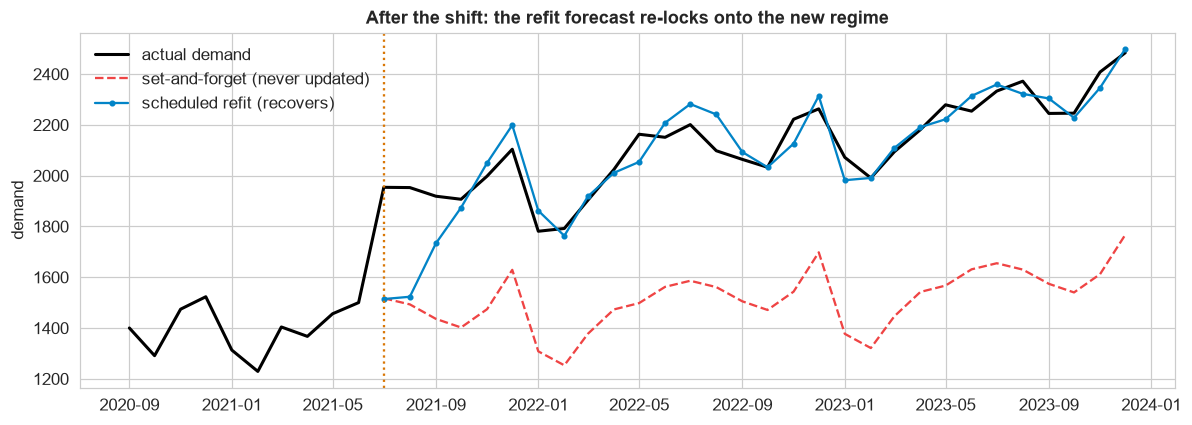

scheduled error at the shift month 23% -> three months later 2% (recovered)


In [11]:
post_shift = log.loc['2021-07':]
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(s.index[-40:], s.values[-40:], color='k', lw=2, label='actual demand')
ax.plot(post_shift.index, post_shift['champion_setforget'], '--', color=RED, label='set-and-forget (never updated)')
ax.plot(post_shift.index, post_shift['scheduled_refit'], 'o-', color=EM, ms=3, label='scheduled refit (recovers)')
ax.axvline(pd.Timestamp('2021-07-01'), color=AMBER, ls=':')
ax.set(title='After the shift: the refit forecast re-locks onto the new regime', ylabel='demand'); ax.legend(); plt.tight_layout(); plt.show()
p = post_shift['sched_ape']; print('scheduled error at the shift month %.0f%% -> three months later %.0f%% (recovered)' % (p.iloc[0], p.iloc[3]))

Because the scheduled pipeline refits every month, within a few months its expanding window has enough post-shift data to <strong>re-lock onto the new regime</strong>: its error spikes to about <strong>23%</strong> at the shift, then falls back to about <strong>2%</strong> three months later. The set-and-forget line just keeps diverging. Scheduled retraining <em>is</em> the recovery, no manual intervention required, which is exactly the point of automating it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 10 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Confirm the recovery held</div>
<div style="color:#4a5578;margin-top:6px">Compare the two pipelines head to head.</div>
</div>

In [12]:
summary = pd.DataFrame({'pipeline':['set-and-forget champion','scheduled monthly refit'],
    'pre_shift_MAPE':[round(log.loc[:'2021-06','champ_ape'].mean(),1), round(log.loc[:'2021-06','sched_ape'].mean(),1)],
    'post_shift_MAPE':[round(log.loc['2021-08':,'champ_ape'].mean(),1), round(log.loc['2021-08':,'sched_ape'].mean(),1)]})
print(summary.to_string(index=False))
print('\nscheduled + monitored keeps MAPE near 3%% throughout; set-and-forget rots to ~28%% after the shift.')

               pipeline  pre_shift_MAPE  post_shift_MAPE
set-and-forget champion             3.0             28.5
scheduled monthly refit             3.1              3.3

scheduled + monitored keeps MAPE near 3%% throughout; set-and-forget rots to ~28%% after the shift.


The verdict is stark: the scheduled, monitored pipeline holds near <strong>3% MAPE</strong> across the whole horizon, while the set-and-forget forecast rots to about <strong>28%</strong> after the shift. Same model, same data, the only difference is that one is <strong>operationalized</strong> and the other is not.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 11 &#183; EMBED &amp; DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Serve the fresh forecast on new data</div>
<div style="color:#4a5578;margin-top:6px">Refit, publish, and let the app consume it.</div>
</div>

In [13]:
# the deployed system: refit on ALL data, publish the next 6 months for the dashboard / order system
final = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
meta2 = {'model':'Holt-Winters','version':'v-latest','trained_through':str(s.index[-1].date()),'n_train':len(s)}
joblib.dump({'model':final,'meta':meta2}, 'forecaster.joblib')
resp = forecast_service(joblib.load('forecaster.joblib'), horizon=6)
print('deployed /forecast response (next 6 months, consumed by the app):')
print('  as_of', resp['as_of'], '| version', resp['version'])
print('  forecast', resp['forecast'])
print('  95% lower', resp['lower']); print('  95% upper', resp['upper'])

deployed /forecast response (next 6 months, consumed by the app):
  as_of 2023-12-01 | version v-latest
  forecast [2205.0, 2155.0, 2271.0, 2362.0, 2406.0, 2454.0]
  95% lower [2058.0, 1979.0, 2072.0, 2141.0, 2174.0, 2193.0]
  95% upper [2352.0, 2327.0, 2466.0, 2560.0, 2640.0, 2696.0]


Deployment closes the loop: the scheduled job refits on <strong>all</strong> data (now including the new regime), repackages the artifact, and the <strong>/forecast endpoint</strong> publishes the next six months with intervals, ready for a dashboard, an app, or the ordering system to consume. Every month it reruns; every month monitoring re-checks accuracy against the floor. The forecast stays alive.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 12 &#183; GOVERN &amp; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Close the loop, in plain English</div>
<div style="color:#4a5578;margin-top:6px">The ops report writes itself.</div>
</div>

<strong>For the operations team:</strong> our demand forecaster is live behind a service the dashboard calls. A one-time forecast would have gone badly stale after the mid-2021 expansion (error near 28%), so we <strong>refit it every month</strong> and <strong>watch its rolling accuracy</strong>; that keeps it near <strong>3%</strong> throughout. If accuracy ever crosses the 10% floor, an alarm fires and we investigate a possible regime change. Bottom line: the forecast is not a one-off number, it is a <strong>monitored service on a schedule</strong>, and that is what keeps it trustworthy.

## The forecasting-ops loop, in one view

1. **Define** the production contract: accuracy floor, refresh cadence, horizon.
2. **Package** the fitted forecaster plus metadata into a versioned artifact.
3. **Serve** it behind a function/API that returns a forecast and interval.
4. **Schedule** a periodic refit on the latest data, the key forecasting habit.
5. **Log** every forecast with its actual when it arrives.
6. **Monitor** rolling forecast accuracy over time.
7. **Detect drift** when rolling error breaches the floor.
8. **Diagnose** a persistent regime change versus a one-off shock.
9-10. **Retrain and validate**: the scheduled refit re-locks onto the new regime.
11. **Embed and deploy**: publish the fresh forecast for the app to consume.
12. **Govern and communicate**: a monitored service on a schedule, not a one-off number.

**The one idea to keep: a forecast is a living service, not a one-time number, so operationalizing it means packaging, serving, scheduling refreshes, and monitoring for drift, because the difference between a 3% and a 28% forecast is not the model, it is whether anyone kept it fresh.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>